# EDA Notebook

This notebook performs exploratory data analysis to identify the activity patterns that separate low, medium, and high mobile money users.

It generates visualizations used in the final report and saves summary results for easy review.

**Instructions:** Run the cells in order. Each cell includes comments explaining what it does and what output to expect.

In [ ]:
# Cell 1: Load data and setup
# This cell loads the cleaned transaction data and user-level features.
# Expected output: Preview of both datasets and record counts.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
base_dir = Path.cwd().parent
cleaned = pd.read_csv(base_dir / '2_Data_Cleaning' / 'cleaned_data.csv', parse_dates=['datetime'])
features = pd.read_csv(base_dir / '4_Modeling' / 'user_features.csv')

# Convert datetime and calculate summary categories if needed.
cleaned['datetime'] = pd.to_datetime(cleaned['datetime'], errors='coerce')
print('Cleaned records:', len(cleaned))
print('User-level feature records:', len(features))

display(cleaned.head())
display(features.head())

,source_file,user_id,date,time,datetime,direction,contact,phone,type,transaction_type,amount,currency,content,status,is_otp,is_promo
0,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-07,15:02:56,2024-06-07 15:02:56,received,MobileMoney,MobileMoney,SMS,balance,100.0,XAF,An adjustment has been made and 100 XAF has be...,success,False,False
1,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-08,17:27:07,2024-06-08 17:27:07,received,MobileMoney,MobileMoney,SMS,balance,8000.0,XAF,Vous avez recu 8000 XAF de IDA FALONE KENFACK ...,success,False,False
2,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-14,00:08:05,2024-06-14 00:08:05,received,MobileMoney,MobileMoney,SMS,balance,100.0,XAF,"Hello, the transaction with amount 100 XAF for...",failed,False,False
3,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-22,19:54:39,2024-06-22 19:54:39,received,MobileMoney,MobileMoney,SMS,balance,450.0,XAF,Vous avez recu 450 XAF de KLOUVIS TAHKEPE MAND...,success,False,False
4,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-23,09:48:39,2024-06-23 09:48:39,received,MobileMoney,MobileMoney,SMS,balance,10000.0,XAF,Vous avez recu 10000 XAF de LIWIR ELIAS (23765...,success,False,False


,user_id,total_transactions,total_transaction_volume,avg_transaction_amount,failed_transactions,deposit_amount,withdraw_amount,transfer_amount,payment_amount,airtime_amount,...,failed_ratio,business_usage,volume_norm,count_norm,avg_amount_norm,freq_norm,activity_score,activity_level,activity_threshold_low,activity_threshold_high
0,msg_2026-03-20_190409,1028,5972090.0,5809.426070,26,155213.0,0.0,0.0,1224.0,1759548.0,...,0.025292,1,3.138208e-06,1.000000,2.062074e-07,1.000000,0.450001,high,0.041317,0.11618
1,msg_2026-03-21_032328,227,1645355.0,7248.259912,5,0.0,0.0,0.0,800.0,473794.0,...,0.022026,1,8.626647e-07,0.216243,2.659884e-07,0.346850,0.123431,high,0.041317,0.11618
2,msg_2026-03-21_185556,40,3389367.0,84734.175000,3,0.0,0.0,610000.0,2005.0,48144.0,...,0.075000,1,1.779886e-06,0.033268,3.485387e-06,0.167560,0.041830,medium,0.041317,0.11618
3,msg_2026-03-21_195936,153,1922611.0,12566.084967,7,15130.0,0.0,0.0,925.0,703961.0,...,0.045752,1,1.008481e-06,0.143836,4.869343e-07,0.351039,0.106167,medium,0.041317,0.11618
4,msg_2026-03-22_213925,51,810073.0,15883.784314,0,0.0,0.0,0.0,0.0,33373.0,...,0.000000,1,4.233680e-07,0.044031,6.247786e-07,0.171582,0.045324,medium,0.041317,0.11618


## Cell 2: Activity Level Distribution
This cell creates a bar chart showing how users are distributed across activity levels.
**Expected output:** A bar plot saved as 'activity_level_distribution.png'.

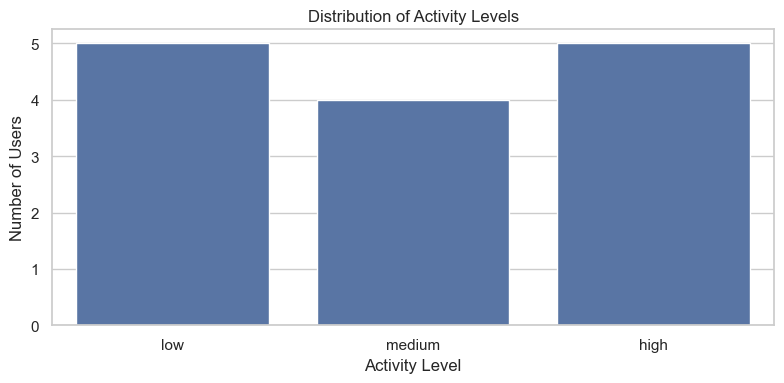

In [5]:
# Plot the distribution of activity levels across users.
plt.figure(figsize=(8, 4))
order = ['low', 'medium', 'high']
sns.countplot(data=features, x='activity_level', order=order)
plt.title('Distribution of Activity Levels')
plt.xlabel('Activity Level')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('activity_level_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 3: Transaction Types
This cell visualizes the frequency of different SMS transaction message types.
**Expected output:** A horizontal bar plot saved as 'transactions_by_type.png'.

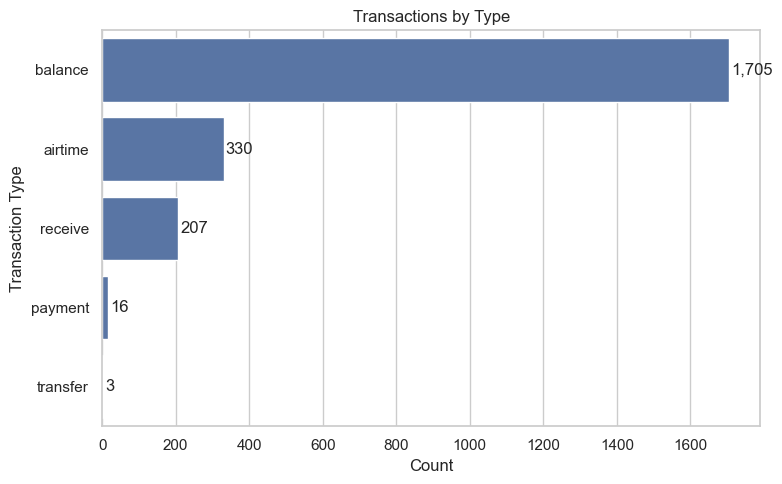

In [6]:
# Visualize the composition of SMS transaction message types.
plt.figure(figsize=(8, 5))
order = cleaned['transaction_type'].value_counts().index
g = sns.countplot(data=cleaned, y='transaction_type', order=order)
plt.title('Transactions by Type')
plt.xlabel('Count')
plt.ylabel('Transaction Type')
for p in g.patches:
    width = p.get_width()
    g.text(width + 5, p.get_y() + p.get_height() / 2, f'{int(width):,}', va='center')
plt.tight_layout()
plt.savefig('transactions_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 4: Volume vs Frequency Scatter Plot
This cell plots total transaction volume against monthly frequency by user segment.
**Expected output:** A scatter plot saved as 'volume_vs_frequency.png'.

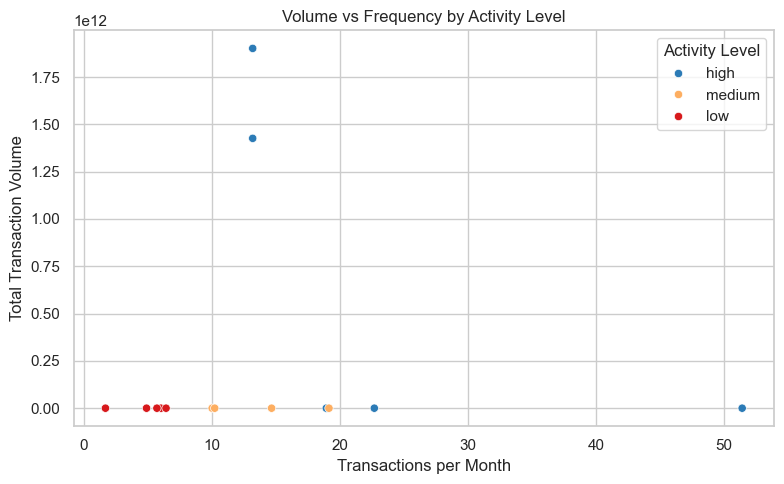

In [7]:
# Compare transaction volume and frequency across activity segments.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=features, x='transactions_per_month', y='total_transaction_volume', hue='activity_level', palette=['#2c7bb6', '#fdae61', '#d7191c'])
plt.title('Volume vs Frequency by Activity Level')
plt.xlabel('Transactions per Month')
plt.ylabel('Total Transaction Volume')
plt.legend(title='Activity Level')
plt.tight_layout()
plt.savefig('volume_vs_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 5: Feature Correlation Heatmap
This cell computes and visualizes correlations between numeric user features.
**Expected output:** A heatmap saved as 'feature_correlation_heatmap.png'.

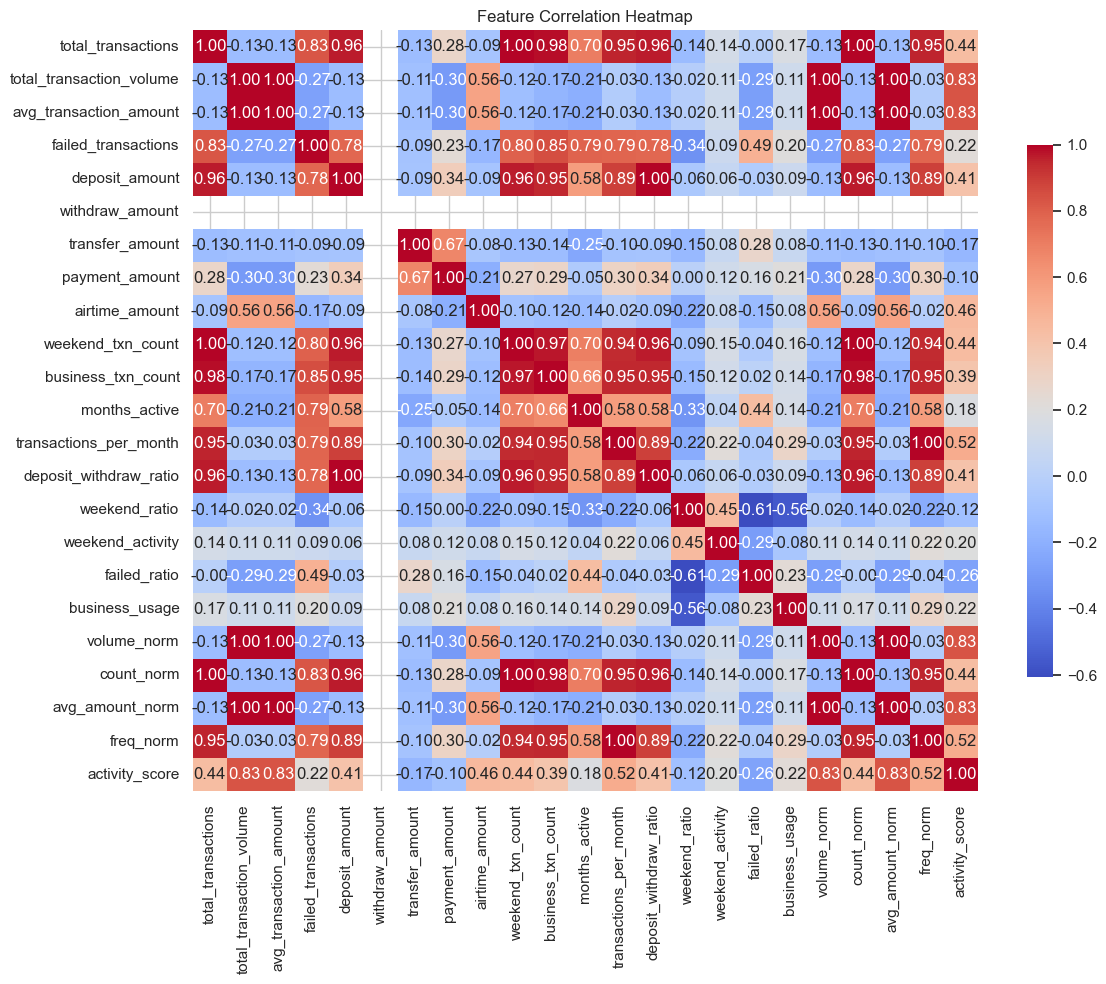

In [8]:
# Compute and visualize the correlation between numeric features.
numeric_features = features.select_dtypes(include=['number']).drop(columns=['activity_threshold_low', 'activity_threshold_high'], errors='ignore')
correlation = numeric_features.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 6: Monthly Transaction Volume Trend
This cell creates a line plot showing transaction volume over time.
**Expected output:** A time series plot saved as 'monthly_transaction_volume.png'.

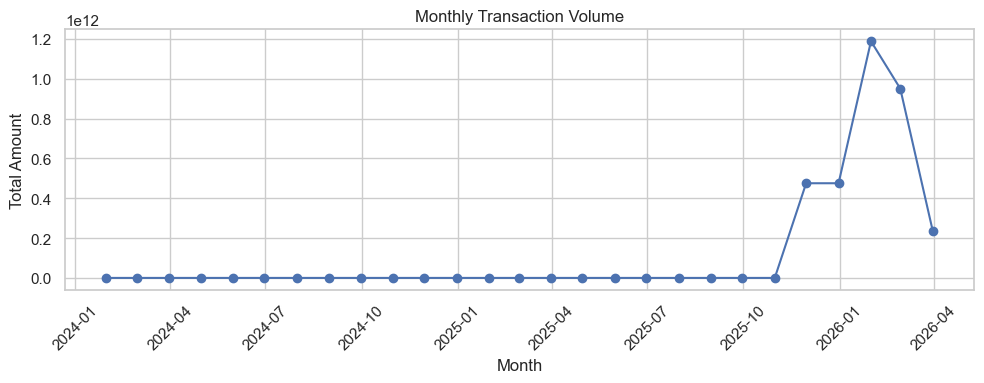

In [16]:
# Create and save a monthly transaction volume trend plot.
monthly_volume = cleaned.set_index('datetime').resample('ME')['amount'].sum().reset_index()
plt.figure(figsize=(10, 4))
plt.plot(monthly_volume['datetime'], monthly_volume['amount'], marker='o')
plt.title('Monthly Transaction Volume')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_transaction_volume.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 7: Weekend Activity Ratio
This cell compares weekend transaction ratios across user segments.
**Expected output:** A box plot saved as 'weekend_activity_ratio.png'.

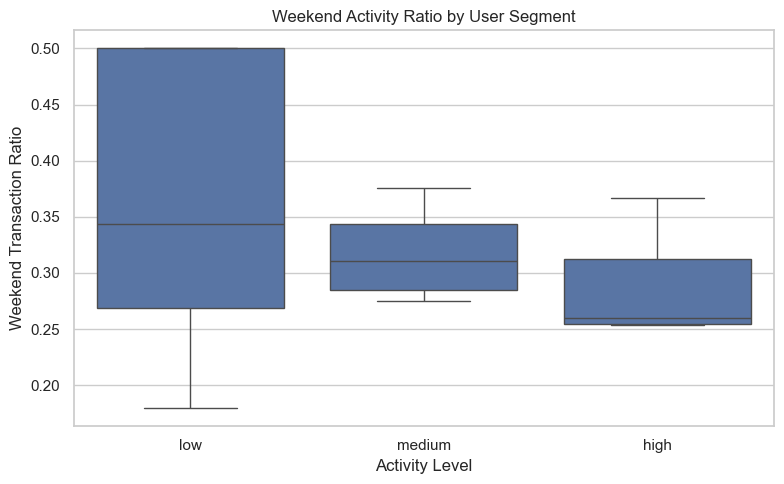

In [17]:
# Compare weekend activity ratio across user segments.
plt.figure(figsize=(8, 5))
activity_order = ['low', 'medium', 'high']
sns.boxplot(data=features, x='activity_level', y='weekend_ratio', order=activity_order)
plt.title('Weekend Activity Ratio by User Segment')
plt.xlabel('Activity Level')
plt.ylabel('Weekend Transaction Ratio')
plt.tight_layout()
plt.savefig('weekend_activity_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 8: EDA Summary Table
This cell generates a summary table of key metrics and saves it as a CSV file.
**Expected output:** A table with user and transaction counts, saved as 'eda_summary.csv'.

In [18]:
# Save a concise EDA summary table for further reference.
edasummary = pd.DataFrame({
    'metric': [
        'unique_users',
        'total_transactions',
        'balance_messages',
        'failed_messages',
        'high_activity_users',
        'medium_activity_users',
        'low_activity_users'
    ],
    'value': [
        features['user_id'].nunique(),
        len(cleaned),
        int((cleaned['transaction_type'] == 'balance').sum()),
        int((cleaned['status'] == 'failed').sum()),
        int((features['activity_level'] == 'high').sum()),
        int((features['activity_level'] == 'medium').sum()),
        int((features['activity_level'] == 'low').sum())
    ]
})
edasummary.to_csv('eda_summary.csv', index=False)
print('Saved eda_summary.csv')
display(edasummary)

Saved eda_summary.csv


,metric,value
0,unique_users,14
1,total_transactions,2261
2,balance_messages,1705
3,failed_messages,77
4,high_activity_users,5
5,medium_activity_users,4
6,low_activity_users,5
